In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
        # print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install timm albumentations grad-cam --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 72.3 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, balanced_accuracy_score)
from sklearn.utils.class_weight import compute_class_weight
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
 
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
 
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
 
print("✅ All imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

✅ All imports successful
PyTorch version: 2.10.0+cu128
GPU available: True


In [4]:
class CFG:
    seed        = 42
    img_size    = 240
    batch_size  = 32
    epochs      = 40
    lr          = 2e-5
    weight_decay= 1e-4
    num_classes = 5
 
    # Focal Loss
    focal_alpha = 1.0
    focal_gamma = 2.0
 
    # Paths (Kaggle)
    data_dir    = '/kaggle/input/datasets/mariaherrerot/aptos2019'
    train_dir   = '/kaggle/input/datasets/mariaherrerot/aptos2019/train_images/train_images'
    valid_dir   = '/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images'    # ← ADD
    test_dir    = '/kaggle/input/datasets/mariaherrerot/aptos2019/test_images/test_images'   # ← ADD
 
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
 
CLASS_NAMES = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']
 
# Reproducibility
torch.manual_seed(CFG.seed)
np.random.seed(CFG.seed)
 
print(f"Device: {CFG.device}")

Device: cuda


In [5]:
train_df = pd.read_csv(f'{CFG.data_dir}/train_1.csv')
valid_df = pd.read_csv(f'{CFG.data_dir}/valid.csv')
test_df  = pd.read_csv(f'{CFG.data_dir}/test.csv')

print(f"Train samples : {len(train_df)}")
print(f"Valid samples : {len(valid_df)}")
print(f"Test samples  : {len(test_df)}")

print(f"\nTrain columns : {train_df.columns.tolist()}")
print(f"Valid columns : {valid_df.columns.tolist()}")
print(f"Test columns  : {test_df.columns.tolist()}")

print(f"\nTrain class distribution:")
print(train_df['diagnosis'].value_counts().sort_index()
      .rename(index=dict(enumerate(CLASS_NAMES))))

if 'diagnosis' in valid_df.columns:
    print(f"\nValid class distribution:")
    print(valid_df['diagnosis'].value_counts().sort_index()
          .rename(index=dict(enumerate(CLASS_NAMES))))

if 'diagnosis' in test_df.columns:
    print(f"\nTest class distribution:")
    print(test_df['diagnosis'].value_counts().sort_index()
          .rename(index=dict(enumerate(CLASS_NAMES))))

Train samples : 2930
Valid samples : 366
Test samples  : 366

Train columns : ['id_code', 'diagnosis']
Valid columns : ['id_code', 'diagnosis']
Test columns  : ['id_code', 'diagnosis']

Train class distribution:
diagnosis
No DR               1434
Mild                 300
Moderate             808
Severe               154
Proliferative DR     234
Name: count, dtype: int64

Valid class distribution:
diagnosis
No DR               172
Mild                 40
Moderate            104
Severe               22
Proliferative DR     28
Name: count, dtype: int64

Test class distribution:
diagnosis
No DR               199
Mild                 30
Moderate             87
Severe               17
Proliferative DR     33
Name: count, dtype: int64


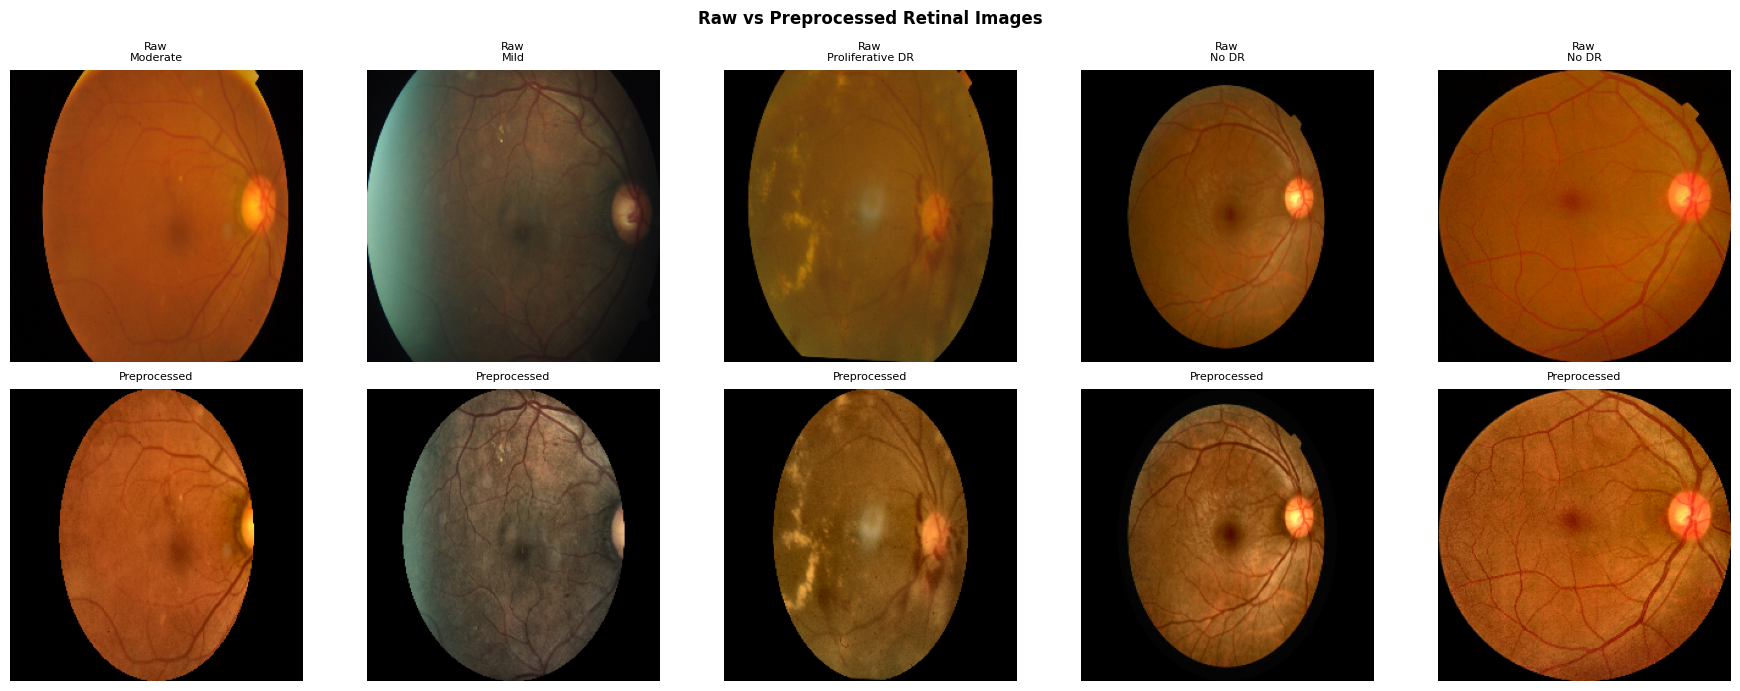

In [6]:
def apply_clahe(img_rgb):
    """Contrast Limited Adaptive Histogram Equalization"""
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    img_bgr = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
 
def apply_circular_mask(img):
    """Remove dark background — keep only the retinal circle"""
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    cx, cy, r = w // 2, h // 2, min(w, h) // 2
    cv2.circle(mask, (cx, cy), r, 255, -1)
    masked = img.copy()
    masked[mask == 0] = 0
    return masked
 
def preprocess_image(img_path, img_size=CFG.img_size):
    """Full preprocessing pipeline: load → CLAHE → mask → resize"""
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Cannot read: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = apply_clahe(img)
    img = apply_circular_mask(img)
    img = cv2.resize(img, (img_size, img_size))
    return img
 
# Quick sanity check — show a few preprocessed images
sample_ids = train_df['id_code'].values[:5]
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i, sid in enumerate(sample_ids):
    raw = cv2.cvtColor(cv2.imread(f'{CFG.train_dir}/{sid}.png'), cv2.COLOR_BGR2RGB)
    raw = cv2.resize(raw, (CFG.img_size, CFG.img_size))
    proc = preprocess_image(f'{CFG.train_dir}/{sid}.png')
    label = train_df.loc[train_df['id_code'] == sid, 'diagnosis'].values[0]
    axes[0][i].imshow(raw);    axes[0][i].set_title(f'Raw\n{CLASS_NAMES[label]}', fontsize=8); axes[0][i].axis('off')
    axes[1][i].imshow(proc);   axes[1][i].set_title('Preprocessed', fontsize=8);               axes[1][i].axis('off')
plt.suptitle('Raw vs Preprocessed Retinal Images', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('preprocessing_samples.png', dpi=150)
plt.show()

In [7]:
class RetinalDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, cache_dir=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform
        self.cache_dir = cache_dir

    def __len__(self):                          # ← THIS WAS MISSING
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache_dir:
            img = np.load(f"{self.cache_dir}/{row['id_code']}.npy")
        else:
            img = preprocess_image(os.path.join(self.img_dir, f"{row['id_code']}.png"))

        if self.transform:
            img = self.transform(image=img)['image']

        return img, int(row['diagnosis'])

In [8]:
# Combine all labeled data
all_df = pd.concat([train_df, valid_df, test_df], ignore_index=True)
print(f"Total samples: {len(all_df)}")
print(all_df['diagnosis'].value_counts().sort_index()
      .rename(index=dict(enumerate(CLASS_NAMES))))

# Split 70% train, 15% val, 15% test — stratified
from sklearn.model_selection import train_test_split

train_df_new, temp_df = train_test_split(
    all_df,
    test_size=0.30,
    random_state=CFG.seed,
    stratify=all_df['diagnosis']
)
val_df_new, test_df_new = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=CFG.seed,
    stratify=temp_df['diagnosis']
)

print(f"\nNew Train: {len(train_df_new)}")
print(f"New Val  : {len(val_df_new)}")
print(f"New Test : {len(test_df_new)}")

print("\nNew Train distribution:")
print(train_df_new['diagnosis'].value_counts().sort_index()
      .rename(index=dict(enumerate(CLASS_NAMES))))
print("\nNew Val distribution:")
print(val_df_new['diagnosis'].value_counts().sort_index()
      .rename(index=dict(enumerate(CLASS_NAMES))))
print("\nNew Test distribution:")
print(test_df_new['diagnosis'].value_counts().sort_index()
      .rename(index=dict(enumerate(CLASS_NAMES))))

Total samples: 3662
diagnosis
No DR               1805
Mild                 370
Moderate             999
Severe               193
Proliferative DR     295
Name: count, dtype: int64

New Train: 2563
New Val  : 549
New Test : 550

New Train distribution:
diagnosis
No DR               1263
Mild                 259
Moderate             699
Severe               135
Proliferative DR     207
Name: count, dtype: int64

New Val distribution:
diagnosis
No DR               271
Mild                 55
Moderate            150
Severe               29
Proliferative DR     44
Name: count, dtype: int64

New Test distribution:
diagnosis
No DR               271
Mild                 56
Moderate            150
Severe               29
Proliferative DR     44
Name: count, dtype: int64


In [9]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
 
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15,
                       rotate_limit=30, border_mode=0, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2,
                               contrast_limit=0.2, p=0.4),
    A.HueSaturationValue(hue_shift_limit=10,
                         sat_shift_limit=20, val_shift_limit=10, p=0.3),
    A.OneOf([
        A.GaussianBlur(blur_limit=3, p=1.0),
        A.MedianBlur(blur_limit=3, p=1.0),
    ], p=0.2),
    A.CoarseDropout(max_holes=8, max_height=16,
                    max_width=16, fill_value=0, p=0.2),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])
 
val_transform = A.Compose([
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

In [10]:
from collections import Counter

# ── Use new proper splits ─────────────────────────────────────
train_df = train_df_new
valid_df  = val_df_new
test_df   = test_df_new

TARGET    = 1000
cache_dir = '/kaggle/working/cached_images'
os.makedirs(cache_dir, exist_ok=True)

aug_save_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15,
                       rotate_limit=30, border_mode=0, p=0.7),
    A.RandomBrightnessContrast(p=0.5),
    A.HueSaturationValue(p=0.3),
])

# ── Cache ALL images (all from train_images folder now) ───────
print("Caching all images...")
for img_dir in [CFG.train_dir, CFG.valid_dir, CFG.test_dir]:
    for fname in os.listdir(img_dir):
        if not fname.endswith('.png'):
            continue
        id_code   = fname.replace('.png', '')
        save_path = f"{cache_dir}/{id_code}.npy"
        if not os.path.exists(save_path):
            try:
                img = preprocess_image(f"{img_dir}/{fname}")
                np.save(save_path, img)
            except Exception:
                pass

print("✅ All images cached!")

# ── Augment ONLY training data ────────────────────────────────
counts = Counter(train_df['diagnosis'].values)
print("\nOriginal train counts:", dict(counts))

augmented_rows = []

for class_id, count in counts.items():
    if count >= TARGET:
        print(f"Class {class_id} ({CLASS_NAMES[class_id]}): {count} — skipping")
        continue

    class_rows = train_df[train_df['diagnosis'] == class_id]
    needed     = TARGET - count
    print(f"Class {class_id} ({CLASS_NAMES[class_id]}): generating {needed} samples...")

    generated = 0
    while generated < needed:
        row     = class_rows.sample(1).iloc[0]
        img     = np.load(f"{cache_dir}/{row['id_code']}.npy")
        aug_img = aug_save_transform(image=img)['image']
        new_id  = f"aug_{class_id}_{generated}"
        np.save(f"{cache_dir}/{new_id}.npy", aug_img)
        augmented_rows.append({'id_code': new_id, 'diagnosis': class_id})
        generated += 1

aug_df       = pd.DataFrame(augmented_rows)
train_df_aug = pd.concat([train_df, aug_df], ignore_index=True)

print("\nAugmented train counts:")
print(train_df_aug['diagnosis'].value_counts().sort_index()
      .rename(index=dict(enumerate(CLASS_NAMES))))

Caching all images...
✅ All images cached!

Original train counts: {np.int64(0): 1263, np.int64(2): 699, np.int64(3): 135, np.int64(1): 259, np.int64(4): 207}
Class 0 (No DR): 1263 — skipping
Class 2 (Moderate): generating 301 samples...
Class 3 (Severe): generating 865 samples...
Class 1 (Mild): generating 741 samples...
Class 4 (Proliferative DR): generating 793 samples...

Augmented train counts:
diagnosis
No DR               1263
Mild                1000
Moderate            1000
Severe              1000
Proliferative DR    1000
Name: count, dtype: int64


In [11]:
# Use train_df_aug for training, valid_df for validation, test_df for final eval
train_data = train_df_aug
val_data   = valid_df    # ← real validation set, no augmentation
test_data  = test_df     # ← real test set, never touched during training

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(CFG.num_classes),
    y=train_data['diagnosis'].values
)
class_weights_tensor = torch.FloatTensor(class_weights).to(CFG.device)

print("Class weights:")
for name, w in zip(CLASS_NAMES, class_weights):
    print(f"  {name:<18} → {w:.4f}")

train_dataset = RetinalDataset(train_data, CFG.train_dir,
                               transform=train_transform, cache_dir=cache_dir)
val_dataset   = RetinalDataset(val_data,   CFG.train_dir,
                               transform=val_transform,   cache_dir=cache_dir)
test_dataset  = RetinalDataset(test_data,  CFG.train_dir,
                               transform=val_transform,   cache_dir=cache_dir)

train_loader = DataLoader(train_dataset, batch_size=CFG.batch_size,
                          shuffle=True,  num_workers=4, pin_memory=True,
                          drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=CFG.batch_size,
                          shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CFG.batch_size,
                          shuffle=False, num_workers=4, pin_memory=True)

print(f"\nTrain samples : {len(train_dataset)}")
print(f"Val samples   : {len(val_dataset)}")
print(f"Test samples  : {len(test_dataset)}")
print(f"Train batches : {len(train_loader)}")

Class weights:
  No DR              → 0.8334
  Mild               → 1.0526
  Moderate           → 1.0526
  Severe             → 1.0526
  Proliferative DR   → 1.0526

Train samples : 5263
Val samples   : 549
Test samples  : 550
Train batches : 164


In [12]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, weight=None, label_smoothing=0.0):
        super().__init__()
        self.alpha           = alpha
        self.gamma           = gamma
        self.weight          = weight
        self.label_smoothing = label_smoothing  # ← ADDED

    def forward(self, inputs, targets):
        ce_loss    = nn.CrossEntropyLoss(
                         weight=self.weight,
                         label_smoothing=self.label_smoothing,  # ← ADDED
                         reduction='none'
                     )(inputs, targets)
        pt         = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()
 

In [13]:
class EfficientNetDR(nn.Module):
    def __init__(self, num_classes=5, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b1', pretrained=True)  # ← B0

        in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

model = EfficientNetDR(num_classes=CFG.num_classes, pretrained=True).to(CFG.device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/31.5M [00:00<?, ?B/s]

Total parameters    : 7,172,645
Trainable parameters: 7,172,645


In [14]:
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()

def train_one_epoch(model, loader, criterion, optimizer, scheduler=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(CFG.device), labels.to(CFG.device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(imgs)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        if scheduler is not None:      # ← null check
            scheduler.step()

        total_loss += loss.item() * imgs.size(0)
        _, preds    = outputs.max(1)
        correct    += preds.eq(labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(CFG.device), labels.to(CFG.device)
            outputs      = model(imgs)
            loss         = criterion(outputs, labels)

            total_loss  += loss.item() * imgs.size(0)
            probs        = torch.softmax(outputs, dim=1)
            _, preds     = outputs.max(1)
            correct     += preds.eq(labels).sum().item()
            total       += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    return total_loss / total, correct / total, bal_acc, \
           all_preds, all_labels, np.array(all_probs)

In [15]:
criterion = FocalLoss(
    alpha=CFG.focal_alpha,
    gamma=CFG.focal_gamma,
    weight=class_weights_tensor
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=CFG.lr,
    weight_decay=CFG.weight_decay
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG.epochs, eta_min=1e-6
)

print("Loss      : Focal Loss + Class Weights")
print("Optimizer : AdamW")
print("Scheduler : CosineAnnealingLR")

Loss      : Focal Loss + Class Weights
Optimizer : AdamW
Scheduler : CosineAnnealingLR


In [16]:
# ── CACHE ALL IMAGES TO DISK (run once, speeds up training 3x) ──
import os
cache_dir = '/kaggle/working/cached_images'
os.makedirs(cache_dir, exist_ok=True)

for idx, row in train_df.iterrows():
    save_path = f"{cache_dir}/{row['id_code']}.npy"
    if not os.path.exists(save_path):  # skip already cached
        img = preprocess_image(f"{CFG.train_dir}/{row['id_code']}.png")
        np.save(save_path, img)

print(f"✅ Cached {len(train_df)} images to {cache_dir}")

✅ Cached 2563 images to /kaggle/working/cached_images


In [17]:
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'val_bal_acc': []
}
best_bal_acc = 0.0
patience     = 10
no_improve   = 0

print(f"\n{'='*70}")
print(f"  Starting Training — {CFG.epochs} epochs on {CFG.device}")
print(f"{'='*70}\n")

for epoch in range(1, CFG.epochs + 1):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer  # no scheduler — steps per epoch below
    )
    val_loss, val_acc, val_bal_acc, preds, labels, probs = validate(
        model, val_loader, criterion
    )
    scheduler.step()   # CosineAnnealingLR steps once per epoch

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_bal_acc'].append(val_bal_acc)

    if val_bal_acc > best_bal_acc:
        best_bal_acc = val_bal_acc
        torch.save(model.state_dict(), 'best_model.pth')
        no_improve = 0
        saved = "  ✅ SAVED"
    else:
        no_improve += 1
        saved = ""
        if no_improve >= patience:
            print(f"⛔ Early stopping at epoch {epoch}")
            break

    print(f"Epoch {epoch:02d}/{CFG.epochs} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  "
          f"BalAcc: {val_bal_acc:.4f}{saved}")

print(f"\n✅ Training complete. Best Balanced Accuracy: {best_bal_acc:.4f}")


  Starting Training — 40 epochs on cuda

Epoch 01/40 | Train Loss: 1.0287  Acc: 0.3325 | Val Loss: 0.4702  Acc: 0.6576  BalAcc: 0.4501  ✅ SAVED
Epoch 02/40 | Train Loss: 0.7460  Acc: 0.4987 | Val Loss: 0.3810  Acc: 0.7541  BalAcc: 0.5613  ✅ SAVED
Epoch 03/40 | Train Loss: 0.5990  Acc: 0.5899 | Val Loss: 0.3226  Acc: 0.7705  BalAcc: 0.5649  ✅ SAVED
Epoch 04/40 | Train Loss: 0.5248  Acc: 0.6290 | Val Loss: 0.3175  Acc: 0.7869  BalAcc: 0.6133  ✅ SAVED
Epoch 05/40 | Train Loss: 0.4658  Acc: 0.6610 | Val Loss: 0.3127  Acc: 0.7942  BalAcc: 0.5927
Epoch 06/40 | Train Loss: 0.4120  Acc: 0.6839 | Val Loss: 0.3009  Acc: 0.7905  BalAcc: 0.6457  ✅ SAVED
Epoch 07/40 | Train Loss: 0.3608  Acc: 0.7193 | Val Loss: 0.3107  Acc: 0.7978  BalAcc: 0.6011
Epoch 08/40 | Train Loss: 0.3259  Acc: 0.7399 | Val Loss: 0.3195  Acc: 0.7978  BalAcc: 0.6028
Epoch 09/40 | Train Loss: 0.2786  Acc: 0.7801 | Val Loss: 0.3142  Acc: 0.8106  BalAcc: 0.6205
Epoch 10/40 | Train Loss: 0.2464  Acc: 0.7973 | Val Loss: 0.3293  A

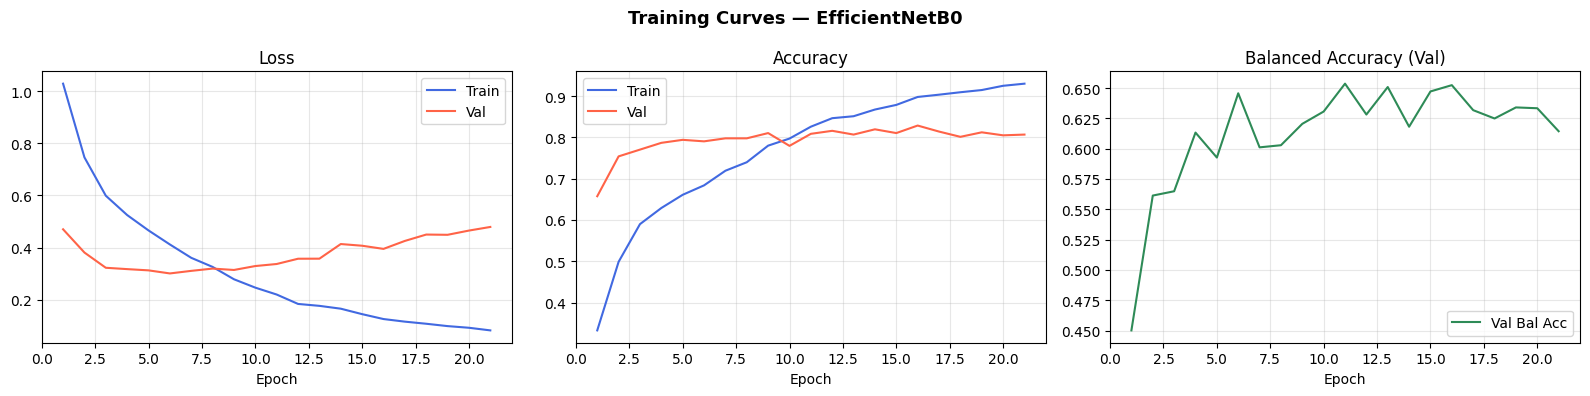

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs_range = range(1, len(history['train_loss']) + 1)  # uses actual epochs run
axes[0].plot(epochs_range, history['train_loss'], label='Train', color='royalblue')
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='tomato')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')
 
axes[1].plot(epochs_range, history['train_acc'], label='Train', color='royalblue')
axes[1].plot(epochs_range, history['val_acc'],   label='Val',   color='tomato')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')
 
axes[2].plot(epochs_range, history['val_bal_acc'], color='seagreen', label='Val Bal Acc')
axes[2].set_title('Balanced Accuracy (Val)'); axes[2].legend(); axes[2].set_xlabel('Epoch')
 
for ax in axes:
    ax.grid(True, alpha=0.3)
 
plt.suptitle('Training Curves — EfficientNetB0', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()


      VALIDATION SET RESULTS
                  precision    recall  f1-score   support

           No DR     0.9705    0.9705    0.9705       271
            Mild     0.5614    0.5818    0.5714        55
        Moderate     0.7372    0.7667    0.7516       150
          Severe     0.4545    0.5172    0.4839        29
Proliferative DR     0.5938    0.4318    0.5000        44

        accuracy                         0.8087       549
       macro avg     0.6635    0.6536    0.6555       549
    weighted avg     0.8083    0.8087    0.8073       549

Balanced Accuracy : 0.6536
AUC (macro OVR)   : 0.9277


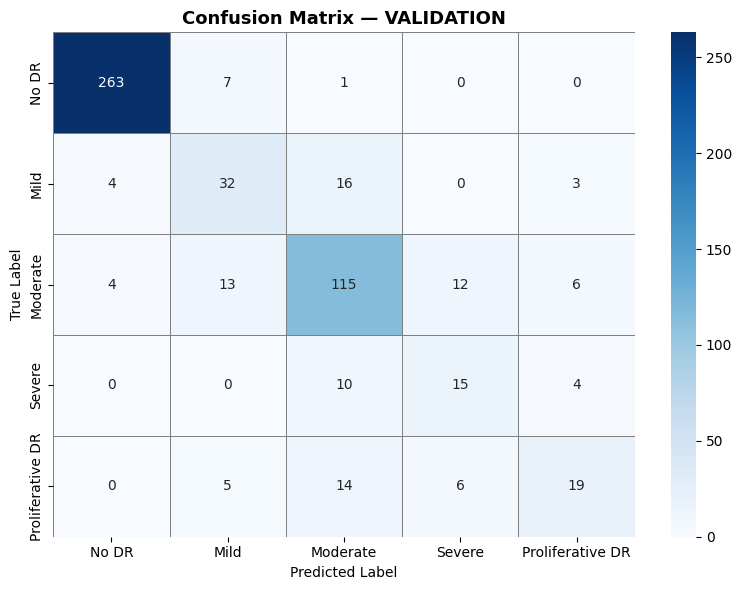


      TEST SET RESULTS
                  precision    recall  f1-score   support

           No DR     0.9636    0.9779    0.9707       271
            Mild     0.4571    0.5714    0.5079        56
        Moderate     0.7153    0.6867    0.7007       150
          Severe     0.3200    0.2759    0.2963        29
Proliferative DR     0.5000    0.4091    0.4500        44

        accuracy                         0.7745       550
       macro avg     0.5912    0.5842    0.5851       550
    weighted avg     0.7733    0.7745    0.7727       550

Balanced Accuracy : 0.5842
AUC (macro OVR)   : 0.9293


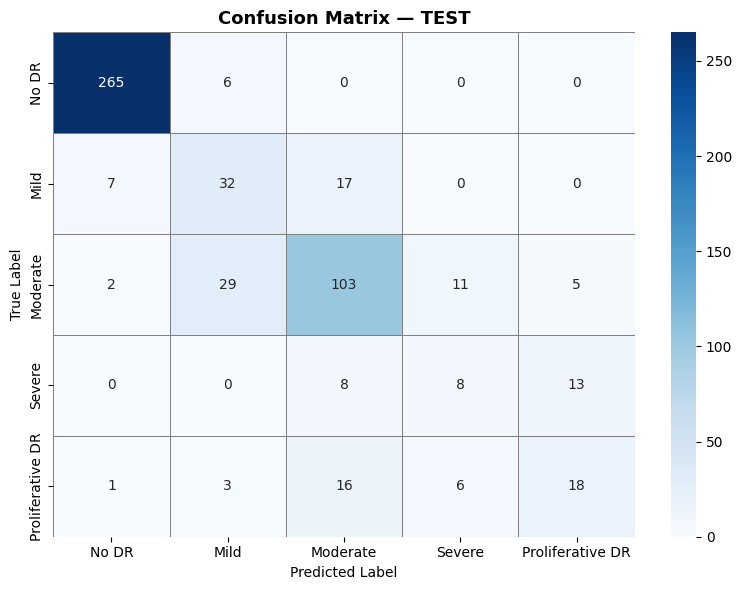

In [19]:
model.load_state_dict(torch.load('best_model.pth'))

for split_name, loader in [('VALIDATION', val_loader), ('TEST', test_loader)]:
    _, _, _, preds, true_labels, probs = validate(model, loader, criterion)

    print("\n" + "="*60)
    print(f"      {split_name} SET RESULTS")
    print("="*60)
    print(classification_report(true_labels, preds,
                                target_names=CLASS_NAMES, digits=4))
    print(f"Balanced Accuracy : {balanced_accuracy_score(true_labels, preds):.4f}")
    try:
        auc = roc_auc_score(true_labels, probs,
                            multi_class='ovr', average='macro')
        print(f"AUC (macro OVR)   : {auc:.4f}")
    except Exception as e:
        print(f"AUC error: {e}")

    cm = confusion_matrix(true_labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, linecolor='gray')
    plt.title(f'Confusion Matrix — {split_name}', fontsize=13, fontweight='bold')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{split_name.lower()}.png', dpi=150)
    plt.show()

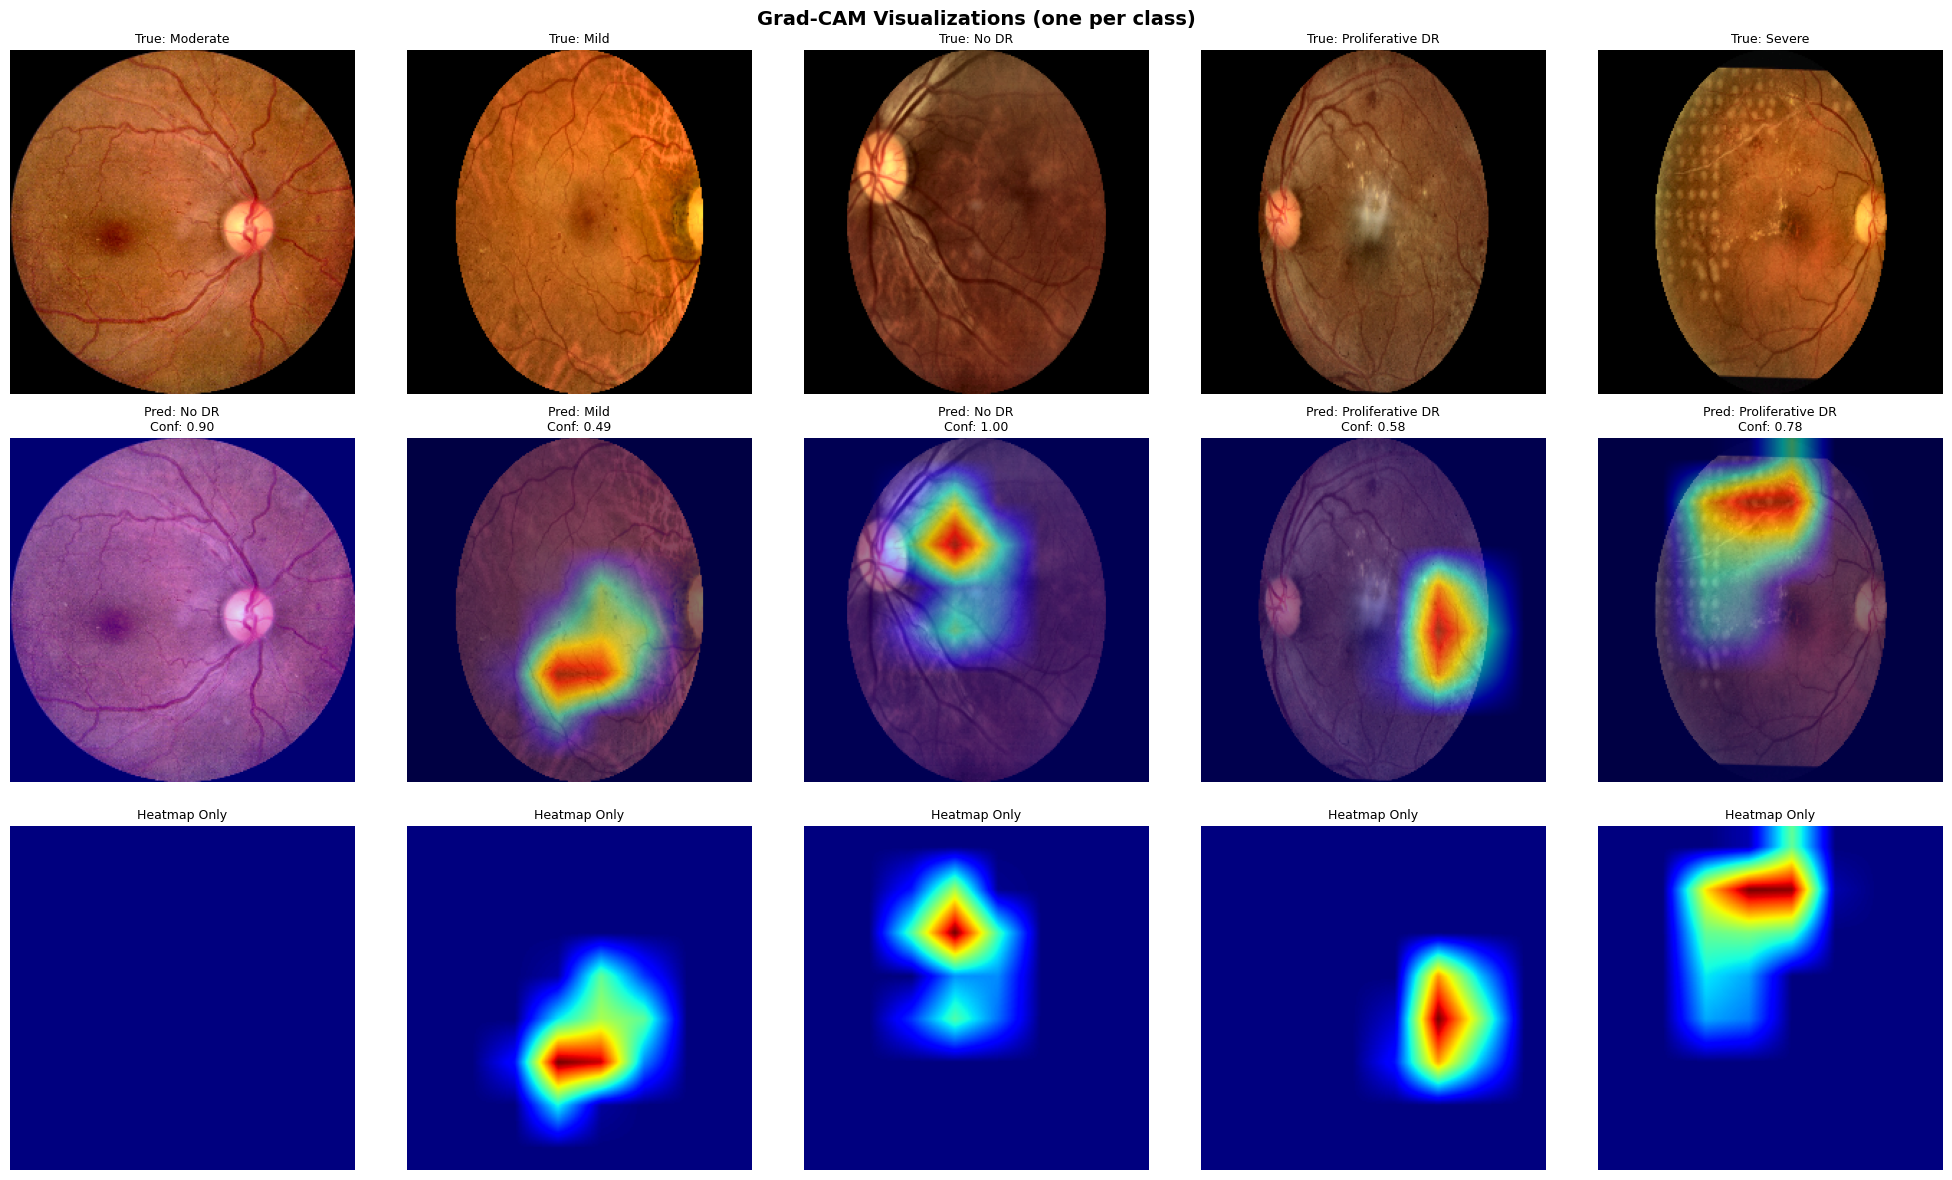

In [20]:
target_layer = [model.backbone.conv_head]

def generate_gradcam(img_tensor, target_class=None):
    cam    = GradCAM(model=model, target_layers=target_layer)
    target = [ClassifierOutputTarget(target_class)] if target_class is not None else None
    cam_map = cam(input_tensor=img_tensor.unsqueeze(0), targets=target)
    return cam_map[0]

model.eval()
fig, axes = plt.subplots(3, 5, figsize=(20, 12))

# Pick one REAL (non-augmented) sample per class
shown   = {i: False for i in range(5)}
samples = []
for _, row in test_data.iterrows():
    label   = int(row['diagnosis'])
    id_code = row['id_code']
    # Skip augmented images — they don't have .png files
    if str(id_code).startswith('aug_'):
        continue
    if not shown[label]:
        samples.append(row)
        shown[label] = True
    if all(shown.values()):
        break

for i, row in enumerate(samples):
    id_code  = row['id_code']

    # Load from cache (works for both real and aug, but we're using real only)
    orig_img  = np.load(f"{cache_dir}/{id_code}.npy")   # ← load from cache
    aug       = val_transform(image=orig_img)
    img_tensor = aug['image'].to(CFG.device)

    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0))
        pred   = output.argmax(1).item()
        conf   = torch.softmax(output, dim=1)[0][pred].item()

    cam_map       = generate_gradcam(img_tensor, target_class=pred)
    rgb_img       = orig_img.astype(np.float32) / 255.0
    visualization = show_cam_on_image(rgb_img, cam_map, use_rgb=True)

    axes[0][i].imshow(orig_img)
    axes[0][i].set_title(f"True: {CLASS_NAMES[int(row['diagnosis'])]}", fontsize=9)
    axes[0][i].axis('off')

    axes[1][i].imshow(visualization)
    axes[1][i].set_title(f"Pred: {CLASS_NAMES[pred]}\nConf: {conf:.2f}", fontsize=9)
    axes[1][i].axis('off')

    axes[2][i].imshow(cam_map, cmap='jet')
    axes[2][i].set_title("Heatmap Only", fontsize=9)
    axes[2][i].axis('off')

plt.suptitle('Grad-CAM Visualizations (one per class)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_visualizations.png', dpi=150)
plt.show()

In [21]:
from scipy.optimize import minimize
from sklearn.metrics import cohen_kappa_score

def qwk(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')

def optimize_thresholds(probs, true_labels):
    # Convert probabilities to continuous score
    scores = np.sum(probs * np.arange(5), axis=1)  # weighted sum
    
    # Initial thresholds
    init_thresholds = [0.5, 1.5, 2.5, 3.5]
    
    def neg_qwk(thresholds):
        preds = np.digitize(scores, sorted(thresholds))
        return -qwk(true_labels, preds)
    
    result = minimize(neg_qwk, init_thresholds, method='Nelder-Mead')
    best_thresholds = sorted(result.x)
    
    final_preds = np.digitize(scores, best_thresholds)
    return final_preds, best_thresholds

# Run after getting probs from validate()
optimized_preds, thresholds = optimize_thresholds(probs, true_labels)
print(f"QWK after optimization: {qwk(true_labels, optimized_preds):.4f}")
print(classification_report(true_labels, optimized_preds, target_names=CLASS_NAMES))

QWK after optimization: 0.8959
                  precision    recall  f1-score   support

           No DR       0.98      0.97      0.97       271
            Mild       0.55      0.50      0.52        56
        Moderate       0.75      0.55      0.63       150
          Severe       0.21      0.83      0.33        29
Proliferative DR       0.50      0.07      0.12        44

        accuracy                           0.73       550
       macro avg       0.60      0.58      0.52       550
    weighted avg       0.79      0.73      0.73       550



In [22]:
# After the loop in Cell 18, add:
# Re-run on test specifically to get probs for threshold optimization
model.load_state_dict(torch.load('best_model.pth'))
_, _, _, test_preds, test_true, test_probs = validate(model, test_loader, criterion)

# Now optimize on test
optimized_preds, thresholds = optimize_thresholds(test_probs, test_true)
print(f"QWK (test, optimized): {qwk(test_true, optimized_preds):.4f}")
print(classification_report(test_true, optimized_preds, target_names=CLASS_NAMES, digits=4))

QWK (test, optimized): 0.8959
                  precision    recall  f1-score   support

           No DR     0.9776    0.9668    0.9722       271
            Mild     0.5490    0.5000    0.5234        56
        Moderate     0.7523    0.5467    0.6332       150
          Severe     0.2069    0.8276    0.3310        29
Proliferative DR     0.5000    0.0682    0.1200        44

        accuracy                         0.7255       550
       macro avg     0.5972    0.5818    0.5160       550
    weighted avg     0.7937    0.7255    0.7320       550

